# Quick Data Audit and Predictive Accuracy

In [2]:
import pandas as pd
df = pd.read_csv("/Users/akanksha/Downloads/compas_final_merged.csv")
df.columns
data = pd.DataFrame(df)
data.head()



,person_id,age,sex,race,decile_score,score_text,priors_count,two_year_recid,c_charge_degree,screening_date,date_of_birth,raw_score,is_completed
0,50844,20,Male,Caucasian,4,Low,NaN,NaN,NaN,2013-01-01 00:00:00,1992-12-05,-2.08,1
1,50848,28,Male,Caucasian,2,Low,NaN,NaN,NaN,2013-01-01 00:00:00,1984-09-16,-2.84,1
2,50855,18,Male,African-American,8,High,NaN,NaN,NaN,2013-01-01 00:00:00,1994-08-25,-1.20,1
3,50850,18,Female,African-American,7,Medium,NaN,NaN,NaN,2013-01-01 00:00:00,1994-10-09,-1.29,1
4,50839,27,Female,African-American,2,Low,NaN,NaN,NaN,2013-01-01 00:00:00,1985-06-29,-2.90,1


In [9]:
data[['race','score_text','two_year_recid']].isna()

,race,score_text,two_year_recid
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
11184,False,False,True
11185,False,False,True
11186,False,False,True
11187,False,False,True


In [10]:
data[['race','score_text','two_year_recid']].isna().mean()

race              0.000000
score_text        0.000000
two_year_recid    0.974975
dtype: float64

In [11]:
work = data.loc[data['two_year_recid'].notna(), ['race','score_text','two_year_recid']].copy()
work = work[work['race'].isin(['African-American','Caucasian'])]
print(work)


                   race score_text  two_year_recid
61     African-American        Low             0.0
78     African-American     Medium             1.0
90     African-American       High             0.0
120    African-American       High             1.0
146    African-American       High             1.0
...                 ...        ...             ...
10906         Caucasian     Medium             0.0
11048         Caucasian        Low             0.0
11077         Caucasian     Medium             0.0
11109  African-American       High             1.0
11121  African-American       High             1.0

[280 rows x 3 columns]


In [15]:
work['two_year_recid'] = work['two_year_recid'].astype(int)
work['score_text'] = work['score_text'].str.strip().str.title()  # 'Low','Medium','High'
work = work[work['score_text'].isin(['Low','Medium','High'])]
print(work)


                   race score_text  two_year_recid
61     African-American        Low               0
78     African-American     Medium               1
90     African-American       High               0
120    African-American       High               1
146    African-American       High               1
...                 ...        ...             ...
10906         Caucasian     Medium               0
11048         Caucasian        Low               0
11077         Caucasian     Medium               0
11109  African-American       High               1
11121  African-American       High               1

[280 rows x 3 columns]


In [18]:
work['predicted_high'] = work['score_text'].apply(lambda x: 1 if x in ['High','Medium'] else 0)

### Build the confusion matrix:
###  For each group count :
TP = predicted 1 and actually 1
TN = predicted 0 and actually 0
FP = predicetd 1 and atually 0
FN = predicted 0 and actually 1

In [19]:
def confusion_counts(df_grp):
    tp = ((df_grp['predicted_high']==1) & (df_grp['two_year_recid']==1)).sum()
    tn = ((df_grp['predicted_high']==0) & (df_grp['two_year_recid']==0)).sum()
    fp = ((df_grp['predicted_high']==1) & (df_grp['two_year_recid']==0)).sum()
    fn = ((df_grp['predicted_high']==0) & (df_grp['two_year_recid']==1)).sum()
    return tp, tn, fp, fn

# Example: compute separately
black = work[work['race']=='African-American']
white = work[work['race']=='Caucasian']

tp_b, tn_b, fp_b, fn_b = confusion_counts(black)
tp_w, tn_w, fp_w, fn_w = confusion_counts(white)

print("African-American:", tp_b, tn_b, fp_b, fn_b)
print("Caucasian:", tp_w, tn_w, fp_w, fn_w)


African-American: 64 52 68 28
Caucasian: 13 21 17 17


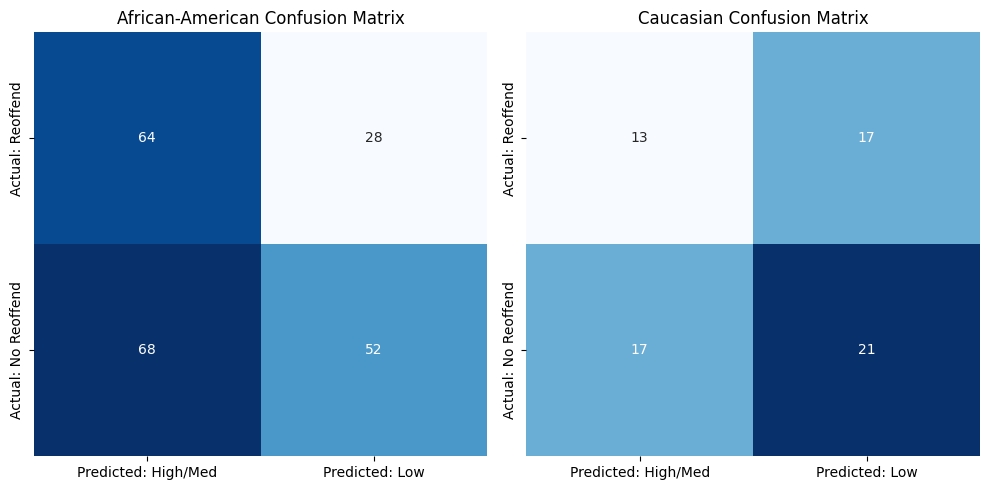

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Confusion matrix data from your earlier results
confusion_data = {
    'African-American': [[64, 28], [68, 52]],   # [[TP, FN], [FP, TN]]
    'Caucasian': [[13, 17], [17, 21]]
}

fig, axes = plt.subplots(1, 2, figsize=(10,5))
for i, (race, matrix) in enumerate(confusion_data.items()):
    df_cm = pd.DataFrame(matrix, 
                         index=['Actual: Reoffend', 'Actual: No Reoffend'],
                         columns=['Predicted: High/Med', 'Predicted: Low'])
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
    axes[i].set_title(f'{race} Confusion Matrix')

plt.tight_layout()
plt.show()


### Performance rate
### False Positive Rate(FPR) = FP/(FP+TN)
   False Negtiave Rate (FNR) = FN/(FN+TP)
   True Positive Rate (TPR) = TP / (TP + FN)
   Accuracy = (TP+TN)/total

In [20]:
def rates(tp, tn, fp, fn):
    FPR = fp / (fp + tn)
    FNR = fn / (fn + tp)
    TPR = tp / (tp + fn)
    ACC = (tp + tn) / (tp + tn + fp + fn)
    return FPR, FNR, TPR, ACC

FPR_b, FNR_b, TPR_b, ACC_b = rates(tp_b, tn_b, fp_b, fn_b)
FPR_w, FNR_w, TPR_w, ACC_w = rates(tp_w, tn_w, fp_w, fn_w)

print(f"Black: FPR={FPR_b:.3f}, FNR={FNR_b:.3f}, Accuracy={ACC_b:.3f}")
print(f"White: FPR={FPR_w:.3f}, FNR={FNR_w:.3f}, Accuracy={ACC_w:.3f}")


Black: FPR=0.567, FNR=0.304, Accuracy=0.547
White: FPR=0.447, FNR=0.567, Accuracy=0.500


### Null Hypothesis (H₀)

### There is no difference in predictive accuracy between African-American and Caucasian defendants.

### True Proportion z-test

The z-test compares two proportions to see if they differ significantly.

For example:

To test FPR difference, you compare FP/(FP+TN) between races.

To test FNR difference, compare FN/(FN+TP) between races.

In [21]:
from statsmodels.stats.proportion import proportions_ztest

# FPR test
count = [fp_b, fp_w]             # "successes" (false positives)
nobs  = [fp_b+tn_b, fp_w+tn_w]   # total non-recidivists
stat_fpr, p_fpr = proportions_ztest(count, nobs)

# FNR test
count = [fn_b, fn_w]             # "successes" (false negatives)
nobs  = [fn_b+tp_b, fn_w+tp_w]   # total recidivists
stat_fnr, p_fnr = proportions_ztest(count, nobs)

print(f"FPR z={stat_fpr:.3f}, p={p_fpr:.4f}")
print(f"FNR z={stat_fnr:.3f}, p={p_fnr:.4f}")


FPR z=1.286, p=0.1986
FNR z=-2.586, p=0.0097


### Summarizing results

In [22]:
summary = pd.DataFrame({
    'Race': ['African-American','Caucasian'],
    'TP':[tp_b,tp_w],'TN':[tn_b,tn_w],'FP':[fp_b,fp_w],'FN':[fn_b,fn_w],
    'FPR':[FPR_b,FPR_w],'FNR':[FNR_b,FNR_w],'Accuracy':[ACC_b,ACC_w]
})
print(summary)
print("\nZ-test p-values:")
print(f"FPR difference p = {p_fpr:.4f}")
print(f"FNR difference p = {p_fnr:.4f}")


               Race  TP  TN  FP  FN       FPR       FNR  Accuracy
0  African-American  64  52  68  28  0.566667  0.304348   0.54717
1         Caucasian  13  21  17  17  0.447368  0.566667   0.50000

Z-test p-values:
FPR difference p = 0.1986
FNR difference p = 0.0097


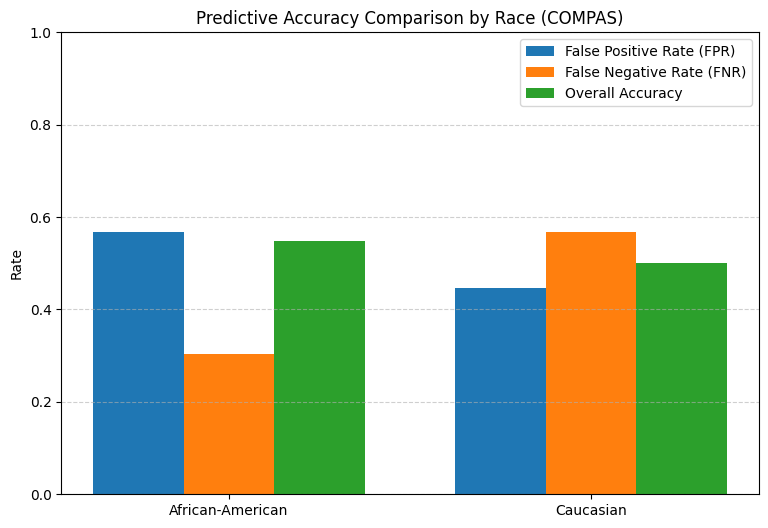

In [24]:
# Example data from our analysis
races = ['African-American', 'Caucasian']
fpr = [0.566667, 0.447368]
fnr = [0.304348, 0.566667]
accuracy = [0.54717, 0.50000]

x = range(len(races))
width = 0.25

plt.figure(figsize=(9,6))
plt.bar([i - width for i in x], fpr, width, label='False Positive Rate (FPR)')
plt.bar(x, fnr, width, label='False Negative Rate (FNR)')
plt.bar([i + width for i in x], accuracy, width, label='Overall Accuracy')

plt.xticks(x, races)
plt.ylabel('Rate')
plt.title('Predictive Accuracy Comparison by Race (COMPAS)')
plt.legend()
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


# Multiple regression analysis ( controlling age, priors )


Variance Inflation Factors (VIF):
       Variable        VIF
0         const  47.447327
1   race_binary   1.014538
2           age   1.018247
3  priors_count   1.005928

Regression Summary:
                            OLS Regression Results                            
Dep. Variable:           decile_score   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     14.07
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           1.46e-08
Time:                        14:25:04   Log-Likelihood:                -622.63
No. Observations:                 280   AIC:                             1253.
Df Residuals:                     276   BIC:                             1268.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   

/var/folders/6m/txkcv3g9175gjx16lkqcbgzh0000gn/T/ipykernel_11634/532791833.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='race', y='predicted_score', data=data, ci=None, palette='Set2')
/var/folders/6m/txkcv3g9175gjx16lkqcbgzh0000gn/T/ipykernel_11634/532791833.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='race', y='predicted_score', data=data, ci=None, palette='Set2')


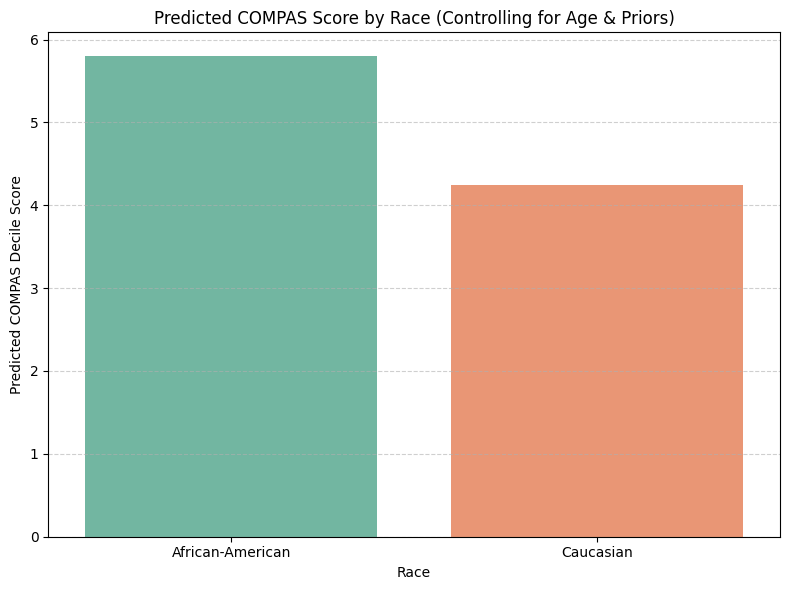

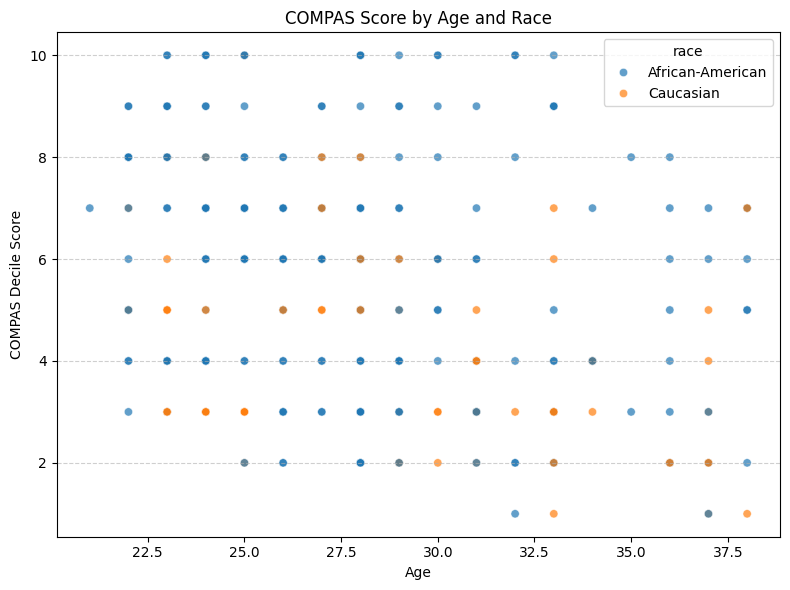

In [29]:
# --- Multiple Regression Analysis Controlling for Age & Priors ---

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Step 2: Keep relevant columns and clean data
cols = ['decile_score', 'race', 'age', 'priors_count']
data = data[cols].dropna()

# Filter for African-American and Caucasian only
data = data[data['race'].isin(['African-American', 'Caucasian'])].copy()

# Encode Race: African-American = 1, Caucasian = 0
data['race_binary'] = data['race'].apply(lambda x: 1 if x == 'African-American' else 0)

# Step 3: Define predictors (X) and target (y)
X = data[['race_binary', 'age', 'priors_count']]
y = data['decile_score']

# Add constant for intercept
X = sm.add_constant(X)

# Step 4: Fit multiple linear regression model
model = sm.OLS(y, X).fit()

# Step 5: Check multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factors (VIF):")
print(vif_data)

# Step 6: Model summary
print("\nRegression Summary:")
print(model.summary())

# Step 7: Predict values for visualization
data['predicted_score'] = model.predict(X)

# --- Visualization 1: Predicted COMPAS Score by Race (Controlling for Age & Priors) ---
plt.figure(figsize=(8,6))
sns.barplot(x='race', y='predicted_score', data=data, ci=None, palette='Set2')
plt.title('Predicted COMPAS Score by Race (Controlling for Age & Priors)')
plt.ylabel('Predicted COMPAS Decile Score')
plt.xlabel('Race')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Visualization 2: Scatter Plot of Age vs COMPAS Score (Colored by Race) ---
plt.figure(figsize=(8,6))
sns.scatterplot(x='age', y='decile_score', hue='race', data=data, alpha=0.7)
plt.title('COMPAS Score by Age and Race')
plt.xlabel('Age')
plt.ylabel('COMPAS Decile Score')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# 3. What drives compas scores ( Linear Regression and Random Forest)

Standardized β coefficients (Linear Regression):
race_binary       0.251205
age              -0.234037
priors_count      0.041849
two_year_recid    0.021456
charge_M         -0.007856
dtype: float64

Random Forest Feature Importances:
age               0.409023
priors_count      0.317439
race_binary       0.094900
charge_M          0.090032
two_year_recid    0.088607
dtype: float64


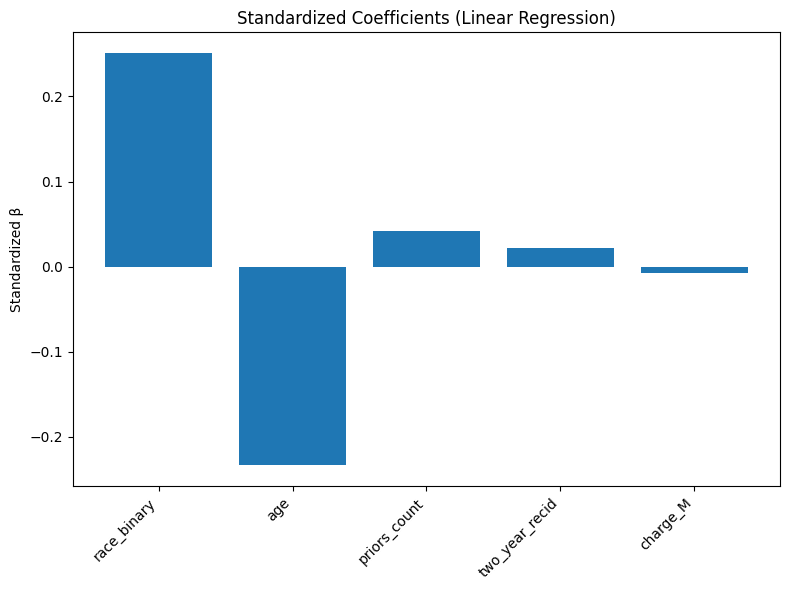

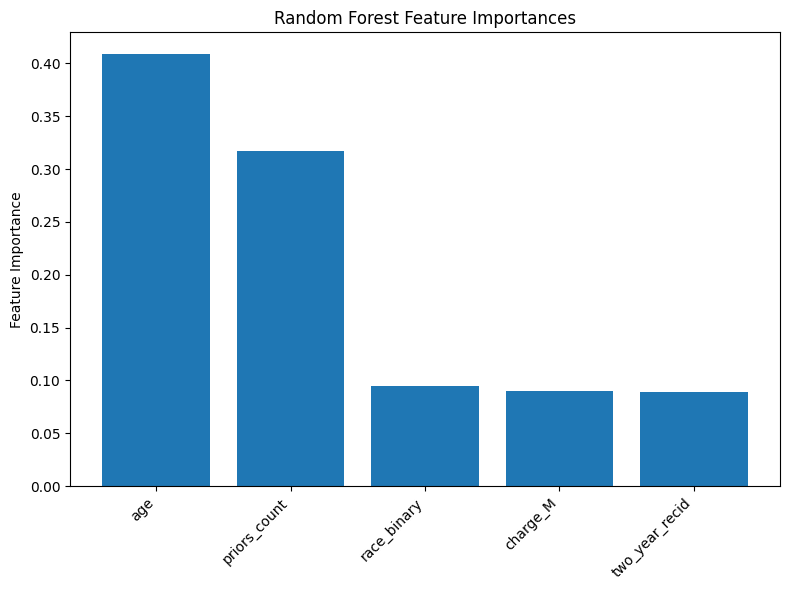

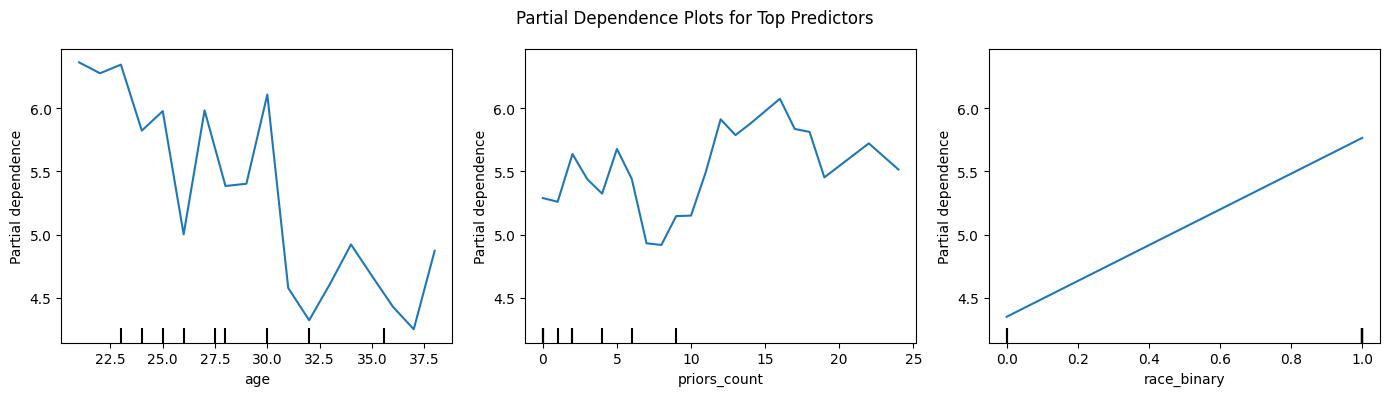


Comparison of Standardized β vs Random Forest Importances:
                Standardized_Beta  RF_Importance
age                     -0.234037       0.409023
priors_count             0.041849       0.317439
race_binary              0.251205       0.094900
charge_M                -0.007856       0.090032
two_year_recid           0.021456       0.088607


In [35]:
# --- Feature Influence Analysis on COMPAS Risk Score ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay

# Step 1: Load dataset
file_path = "/Users/akanksha/Downloads/compas_final_merged.csv"
df = pd.read_csv(file_path)

# Step 2: Select and clean variables
use = df[['decile_score', 'age', 'priors_count', 'race', 'c_charge_degree', 'two_year_recid']].copy()
use = use.dropna(subset=['decile_score', 'age', 'priors_count', 'race', 'c_charge_degree', 'two_year_recid'])
use = use[use['race'].isin(['African-American', 'Caucasian'])].copy()

# Step 3: Encode categorical variables
use['race_binary'] = (use['race'] == 'African-American').astype(int)
charge_dummies = pd.get_dummies(use['c_charge_degree'], prefix='charge', drop_first=True)
use = pd.concat([use.drop(columns=['race', 'c_charge_degree']), charge_dummies], axis=1)

# Step 4: Define features (X) and target (y)
y = use['decile_score'].astype(float)
X = use.drop(columns=['decile_score']).astype(float)
feature_names = list(X.columns)

# Step 5: Standardize X and y for Linear Regression
X_scaler = StandardScaler()
y_scaler = StandardScaler()
X_z = X_scaler.fit_transform(X)
y_z = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()

# Step 6: Fit Linear Regression (for standardized β coefficients)
lin = LinearRegression(fit_intercept=False)
lin.fit(X_z, y_z)
beta_std = pd.Series(lin.coef_, index=feature_names).sort_values(key=lambda s: s.abs(), ascending=False)
print("Standardized β coefficients (Linear Regression):")
print(beta_std)

# Step 7: Fit Random Forest Regressor (for feature importance)
rf = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\nRandom Forest Feature Importances:")
print(rf_imp)

# Step 8: Visualize standardized coefficients
plt.figure(figsize=(8,6))
plt.bar(range(len(beta_std)), beta_std.values)
plt.xticks(range(len(beta_std)), beta_std.index, rotation=45, ha='right')
plt.ylabel('Standardized β')
plt.title('Standardized Coefficients (Linear Regression)')
plt.tight_layout()
plt.show()

# Step 9: Visualize Random Forest feature importances
plt.figure(figsize=(8,6))
plt.bar(range(len(rf_imp)), rf_imp.values)
plt.xticks(range(len(rf_imp)), rf_imp.index, rotation=45, ha='right')
plt.ylabel('Feature Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

# Step 10: Partial Dependence Plots (Top 3 RF Predictors)
top3 = list(rf_imp.head(3).index)
fig, ax = plt.subplots(1, 3, figsize=(14,4))
PartialDependenceDisplay.from_estimator(rf, X, features=top3, ax=ax)
fig.suptitle('Partial Dependence Plots for Top Predictors')
plt.tight_layout()
plt.show()

# Step 11: Comparison Table
comp = pd.DataFrame({
    'Standardized_Beta': beta_std.reindex(feature_names).values,
    'RF_Importance': rf_imp.reindex(feature_names).values
}, index=feature_names)
print("\nComparison of Standardized β vs Random Forest Importances:")
print(comp.sort_values('RF_Importance', ascending=False))


# Calibration

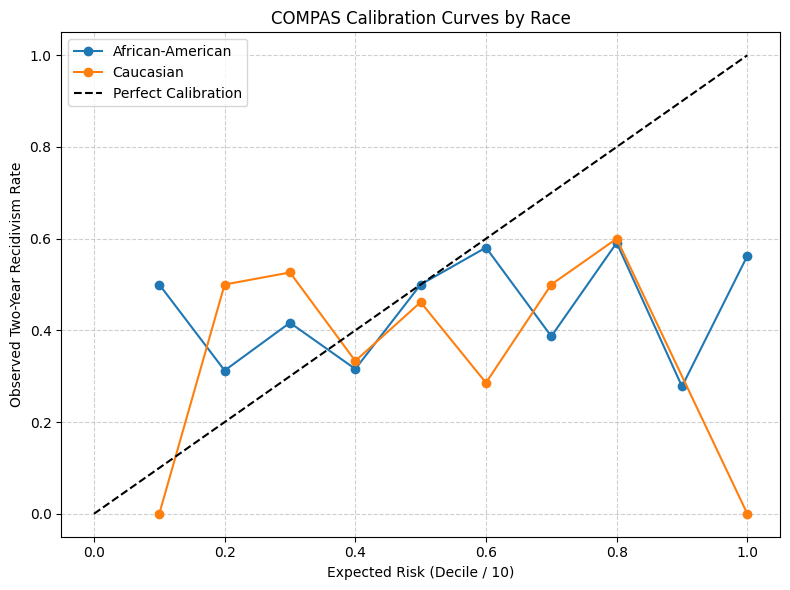


=== Brier Scores ===
African-American: 0.304
Caucasian: 0.286

=== Hosmer–Lemeshow Test Results ===
African-American: χ² = inf, p = 0.0000
Caucasian: χ² = 17.12, p = 0.0289

=== Calibration Table (first few rows) ===
               race  decile_score  Observed_RecidRate   N  Expected_Risk
0  African-American             1            0.500000   2            0.1
1  African-American             2            0.312500  16            0.2
2  African-American             3            0.416667  24            0.3
3  African-American             4            0.315789  38            0.4
4  African-American             5            0.500000  14            0.5


/var/folders/6m/txkcv3g9175gjx16lkqcbgzh0000gn/T/ipykernel_11634/24784431.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs = df_hl.groupby('group')['y'].agg(['sum','count'])
/var/folders/6m/txkcv3g9175gjx16lkqcbgzh0000gn/T/ipykernel_11634/24784431.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exp = df_hl.groupby('group')['p'].sum()
/var/folders/6m/txkcv3g9175gjx16lkqcbgzh0000gn/T/ipykernel_11634/24784431.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to a

In [36]:
# --- Calibration Analysis Across Racial Groups ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
from scipy.stats import chi2

# Step 1: Load dataset
file_path = "/Users/akanksha/Downloads/compas_final_merged.csv"
df = pd.read_csv(file_path)

# Step 2: Select relevant variables
cols = ['decile_score', 'race', 'two_year_recid']
data = df[cols].dropna()
data = data[data['race'].isin(['African-American', 'Caucasian'])]

# Step 3: Ensure decile_score is integer (1–10)
data['decile_score'] = data['decile_score'].astype(int)

# Step 4: Compute observed recidivism rate per decile and race
calibration = (
    data.groupby(['race', 'decile_score'])['two_year_recid']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Observed_RecidRate', 'count': 'N'})
    .reset_index()
)
calibration['Expected_Risk'] = calibration['decile_score'] / 10

# Step 5: Plot calibration curves for each race
plt.figure(figsize=(8,6))
for race in calibration['race'].unique():
    subset = calibration[calibration['race'] == race]
    plt.plot(subset['Expected_Risk'], subset['Observed_RecidRate'], marker='o', label=race)

plt.plot([0,1], [0,1], 'k--', label='Perfect Calibration')
plt.title('COMPAS Calibration Curves by Race')
plt.xlabel('Expected Risk (Decile / 10)')
plt.ylabel('Observed Two-Year Recidivism Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Step 6: Compute Brier Scores (lower = better calibration)
brier_scores = {}
for race in ['African-American', 'Caucasian']:
    subset = data[data['race'] == race]
    y_true = subset['two_year_recid'].astype(int)
    y_prob = subset['decile_score'] / 10
    brier_scores[race] = brier_score_loss(y_true, y_prob)

# Step 7: Hosmer–Lemeshow goodness-of-fit test
def hosmer_lemeshow_test(y_true, y_prob, g=10):
    df_hl = pd.DataFrame({'y': y_true, 'p': y_prob})
    df_hl['group'] = pd.qcut(df_hl['p'], g, duplicates='drop')
    obs = df_hl.groupby('group')['y'].agg(['sum','count'])
    exp = df_hl.groupby('group')['p'].sum()
    hl_stat = np.sum((obs['sum'] - exp)**2 / (exp * (1 - exp / obs['count'])))
    p_val = 1 - chi2.cdf(hl_stat, g-2)
    return hl_stat, p_val

hl_results = {}
for race in ['African-American', 'Caucasian']:
    subset = data[data['race'] == race]
    y_true = subset['two_year_recid'].astype(int)
    y_prob = subset['decile_score'] / 10
    hl_results[race] = hosmer_lemeshow_test(y_true, y_prob)

# Step 8: Display results
print("\n=== Brier Scores ===")
for race, score in brier_scores.items():
    print(f"{race}: {score:.3f}")

print("\n=== Hosmer–Lemeshow Test Results ===")
for race, (hl_stat, p_val) in hl_results.items():
    print(f"{race}: χ² = {hl_stat:.2f}, p = {p_val:.4f}")

print("\n=== Calibration Table (first few rows) ===")
print(calibration.head())
